In [1]:
# =============================================================================
# ETAPA 2: MODELAGEM PREDITIVA - VERSÃO COMPLETA E DETALHADA
# =============================================================================

print("🚀 INICIANDO ETAPA 2: MODELAGEM PREDITIVA")
print("=" * 70)

# =============================================================================
# 1. CONFIGURAÇÃO INICIAL E IMPORTAÇÕES
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score,
                             classification_report, confusion_matrix, roc_curve, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("✅ BIBLIOTECAS CONFIGURADAS")

🚀 INICIANDO ETAPA 2: MODELAGEM PREDITIVA
✅ BIBLIOTECAS CONFIGURADAS


In [2]:
# =============================================================================
# 2. CARREGAMENTO DOS DADOS DO GOOGLE DRIVE
# =============================================================================

from google.colab import drive
import sys

print("📁 CONECTANDO AO GOOGLE DRIVE...")
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/TCC_COMPAS'
sys.path.append(f'{base_path}/utils')

from data_loader import load_compas_data

print("📥 CARREGANDO DADOS PROCESSADOS...")
data = load_compas_data()
df_principal = data['df_principal']
bias_df = data['bias_df']
metadata = data['metadata']

print(f"✅ DADOS CARREGADOS: {df_principal.shape}")
print(f"👥 Distribuição racial: {df_principal['race'].value_counts(normalize=True).round(3).to_dict()}")

📁 CONECTANDO AO GOOGLE DRIVE...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📥 CARREGANDO DADOS PROCESSADOS...
✅ DADOS CARREGADOS COM SUCESSO!
📊 Dataset: (5278, 54)
📈 Métricas de viés: (2, 11)
🕐 Processado em: 2025-10-12 18:02:31
👥 Casos: 5278
✅ DADOS CARREGADOS: (5278, 54)
👥 Distribuição racial: {'African-American': 0.602, 'Caucasian': 0.398}


In [3]:
# =============================================================================
# 3. DEFINIÇÃO DE FEATURES, TARGET E SPLIT DOS DADOS
# =============================================================================

print("🎯 CONFIGURANDO FEATURES E TARGET...")

# Features selecionadas (sem vazamento do COMPAS)
features = [
    'race', 'sex', 'age_cat',
    'c_charge_degree', 'priors_count',
    'juv_fel_count', 'juv_misd_count', 'juv_other_count'
]
target = 'two_year_recid'

categorical_features = ['race', 'sex', 'age_cat', 'c_charge_degree']
numerical_features = ['priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count']

X = df_principal[features]
y = df_principal[target]

print("✅ FEATURES SELECIONADAS:")
for i, feat in enumerate(features, 1):
    print(f"   {i:2d}. {feat}")

print(f"\n📊 Balanceamento do target: {y.mean():.3f}")

🎯 CONFIGURANDO FEATURES E TARGET...
✅ FEATURES SELECIONADAS:
    1. race
    2. sex
    3. age_cat
    4. c_charge_degree
    5. priors_count
    6. juv_fel_count
    7. juv_misd_count
    8. juv_other_count

📊 Balanceamento do target: 0.470


In [4]:
# =============================================================================
# 4. SPLIT ESTRATIFICADO E BASELINE COMPAS
# =============================================================================

print("📊 DIVIDINDO DADOS E ESTABELECENDO BASELINE...")

# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=df_principal[['two_year_recid', 'race']]
)

grupos_raciais_test = X_test['race']

print("✅ SPLIT CONCLUÍDO:")
print(f"   • Treino: {X_train.shape} ({y_train.mean():.3f} positiva)")
print(f"   • Teste:  {X_test.shape} ({y_test.mean():.3f} positiva)")

# Baseline COMPAS
compas_predictions = (df_principal['score_text'].isin(['High', 'Medium'])).astype(int)
compas_auc = roc_auc_score(y, compas_predictions)
compas_accuracy = accuracy_score(y, compas_predictions)

print(f"\n📈 BASELINE COMPAS:")
print(f"   • ROC-AUC: {compas_auc:.4f}")
print(f"   • Acurácia: {compas_accuracy:.4f}")

# Configurar validação cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados_gerais = {}

📊 DIVIDINDO DADOS E ESTABELECENDO BASELINE...
✅ SPLIT CONCLUÍDO:
   • Treino: (4222, 8) (0.470 positiva)
   • Teste:  (1056, 8) (0.471 positiva)

📈 BASELINE COMPAS:
   • ROC-AUC: 0.6575
   • Acurácia: 0.6582


In [5]:
# =============================================================================
# 5. FUNÇÕES UTILITÁRIAS PARA ANÁLISE
# =============================================================================

def calcular_metricas_fairness(y_true, y_pred, grupos_raciais):
    """Calcula métricas de fairness por grupo racial"""
    resultados = {}

    for race in ['African-American', 'Caucasian']:
        mask = grupos_raciais == race
        y_true_race = y_true[mask]
        y_pred_race = y_pred[mask]

        if len(y_true_race) > 0:
            tn, fp, fn, tp = confusion_matrix(y_true_race, y_pred_race).ravel()
            fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
            fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
            tpr = tp / (tp + fn) if (tp + fn) > 0 else 0

            resultados[race] = {
                'fpr': fpr, 'fnr': fnr, 'tpr': tpr,
                'precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
                'n_casos': len(y_true_race)
            }

    fpr_aa = resultados['African-American']['fpr']
    fpr_caucasian = resultados['Caucasian']['fpr']
    resultados['disparity_ratio'] = fpr_aa / fpr_caucasian if fpr_caucasian > 0 else float('inf')
    resultados['fpr_difference'] = fpr_aa - fpr_caucasian

    return resultados

def plotar_curva_roc_comparativa(modelos_resultados, y_test):
    """Plota curvas ROC comparativas"""
    plt.figure(figsize=(10, 8))

    # COMPAS
    compas_probs = (df_principal['score_text'].isin(['High', 'Medium'])).astype(int)
    fpr_compas, tpr_compas, _ = roc_curve(y, compas_probs)
    auc_compas = roc_auc_score(y, compas_probs)
    plt.plot(fpr_compas, tpr_compas, 'k--', alpha=0.7, label=f'COMPAS (AUC = {auc_compas:.3f})')

    # Modelos treinados
    for nome, resultados in modelos_resultados.items():
        if nome != 'COMPAS' and hasattr(resultados['model'], 'predict_proba'):
            y_proba = resultados['model'].predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            auc_score = roc_auc_score(y_test, y_proba)
            plt.plot(fpr, tpr, linewidth=2, label=f'{nome} (AUC = {auc_score:.3f})')

    plt.plot([0, 1], [0, 1], 'k-', alpha=0.3, label='Aleatório (AUC = 0.5)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('📊 COMPARAÇÃO DE CURVAS ROC - TODOS OS MODELOS', fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("✅ FUNÇÕES CONFIGURADAS")

✅ FUNÇÕES CONFIGURADAS


In [6]:
# =============================================================================
# 4.5 ARMAZENAR BASELINE COMPAS NOS RESULTADOS
# =============================================================================

print("📈 CONFIGURANDO BASELINE COMPAS NOS RESULTADOS...")

# Calcular métricas do COMPAS para armazenar
compas_predictions = (df_principal['score_text'].isin(['High', 'Medium'])).astype(int)
compas_fairness = calcular_metricas_fairness(y, compas_predictions, df_principal['race'])

resultados_gerais['COMPAS'] = {
    'roc_auc': roc_auc_score(y, compas_predictions),
    'accuracy': accuracy_score(y, compas_predictions),
    'f1_score': f1_score(y, compas_predictions),
    'fpr_aa': compas_fairness['African-American']['fpr'],
    'fpr_caucasian': compas_fairness['Caucasian']['fpr'],
    'fpr_ratio': compas_fairness['disparity_ratio'],
    'cv_mean': 'N/A',
    'cv_std': 'N/A',
    'model': None  # COMPAS não é um modelo treinado por nós
}

print(f"✅ BASELINE COMPAS ARMAZENADA:")
print(f"   • ROC-AUC: {resultados_gerais['COMPAS']['roc_auc']:.4f}")
print(f"   • FPR Ratio: {resultados_gerais['COMPAS']['fpr_ratio']:.2f}x")

📈 CONFIGURANDO BASELINE COMPAS NOS RESULTADOS...
✅ BASELINE COMPAS ARMAZENADA:
   • ROC-AUC: 0.6575
   • FPR Ratio: 1.92x


🎯 MODELO 1: REGRESSÃO LOGÍSTICA
🤖 TREINANDO MODELO...
✅ MÉTRICAS DE PERFORMANCE:
   • ROC-AUC: 0.7052 (CV: 0.7231 ± 0.0335)
   • Acurácia: 0.6619
   • F1-Score: 0.6254

⚖️ MÉTRICAS DE FAIRNESS:
   • FPR African-American: 0.383
   • FPR Caucasian: 0.164
   • FPR Ratio: 2.33x


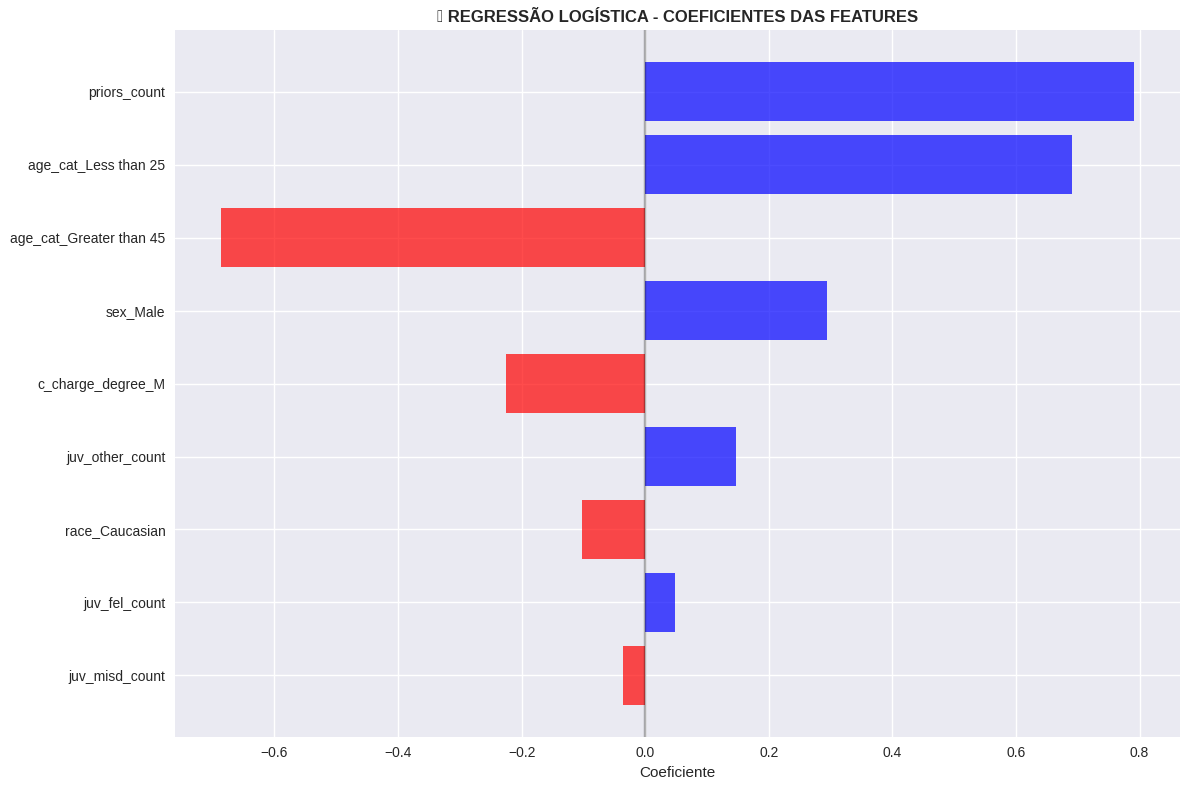

📊 TOP 5 FEATURES MAIS INFLUENTES:


,feature,coefficient,abs_coefficient
0,priors_count,0.791438,0.791438
7,age_cat_Less than 25,0.690095,0.690095
6,age_cat_Greater than 45,-0.687126,0.687126
5,sex_Male,0.294326,0.294326
8,c_charge_degree_M,-0.225263,0.225263


In [7]:
# =============================================================================
# 6. MODELO 1: REGRESSÃO LOGÍSTICA
# =============================================================================

print("🎯 MODELO 1: REGRESSÃO LOGÍSTICA")
print("=" * 50)

# Pré-processamento específico
logreg_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

# Pipeline e treino
logreg_pipeline = Pipeline([
    ('preprocessor', logreg_preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
])

print("🤖 TREINANDO MODELO...")
cv_scores_logreg = cross_val_score(logreg_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
logreg_pipeline.fit(X_train, y_train)

# Predições e métricas
y_pred_logreg = logreg_pipeline.predict(X_test)
y_proba_logreg = logreg_pipeline.predict_proba(X_test)[:, 1]

logreg_auc = roc_auc_score(y_test, y_proba_logreg)
logreg_accuracy = accuracy_score(y_test, y_pred_logreg)
logreg_f1 = f1_score(y_test, y_pred_logreg)

print("✅ MÉTRICAS DE PERFORMANCE:")
print(f"   • ROC-AUC: {logreg_auc:.4f} (CV: {cv_scores_logreg.mean():.4f} ± {cv_scores_logreg.std() * 2:.4f})")
print(f"   • Acurácia: {logreg_accuracy:.4f}")
print(f"   • F1-Score: {logreg_f1:.4f}")

# Análise de fairness
fairness_logreg = calcular_metricas_fairness(y_test, y_pred_logreg, grupos_raciais_test)
print(f"\n⚖️ MÉTRICAS DE FAIRNESS:")
print(f"   • FPR African-American: {fairness_logreg['African-American']['fpr']:.3f}")
print(f"   • FPR Caucasian: {fairness_logreg['Caucasian']['fpr']:.3f}")
print(f"   • FPR Ratio: {fairness_logreg['disparity_ratio']:.2f}x")

# Análise de coeficientes
logreg_model = logreg_pipeline.named_steps['classifier']
preprocessor = logreg_pipeline.named_steps['preprocessor']
feature_names = numerical_features + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))

coeficientes_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': logreg_model.coef_[0],
    'abs_coefficient': np.abs(logreg_model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

plt.figure(figsize=(12, 8))
top_coef = coeficientes_df.head(15)
colors = ['red' if x < 0 else 'blue' for x in top_coef['coefficient']]
plt.barh(top_coef['feature'], top_coef['coefficient'], color=colors, alpha=0.7)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.xlabel('Coeficiente')
plt.title('🔍 REGRESSÃO LOGÍSTICA - COEFICIENTES DAS FEATURES', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("📊 TOP 5 FEATURES MAIS INFLUENTES:")
display(coeficientes_df.head(5))

# Armazenar resultados
resultados_gerais['Logistic Regression'] = {
    'roc_auc': logreg_auc, 'accuracy': logreg_accuracy, 'f1_score': logreg_f1,
    'fpr_aa': fairness_logreg['African-American']['fpr'],
    'fpr_caucasian': fairness_logreg['Caucasian']['fpr'],
    'fpr_ratio': fairness_logreg['disparity_ratio'], 'cv_mean': cv_scores_logreg.mean(),
    'cv_std': cv_scores_logreg.std(), 'model': logreg_pipeline,
    'coeficientes': coeficientes_df
}


🎯 MODELO 2: ÁRVORE DE DECISÃO
🤖 TREINANDO MODELO...
✅ MÉTRICAS DE PERFORMANCE:
   • ROC-AUC: 0.6973 (CV: 0.7111 ± 0.0281)
   • Acurácia: 0.6581
   • F1-Score: 0.6267

⚖️ MÉTRICAS DE FAIRNESS:
   • FPR African-American: 0.373
   • FPR Caucasian: 0.211
   • FPR Ratio: 1.77x


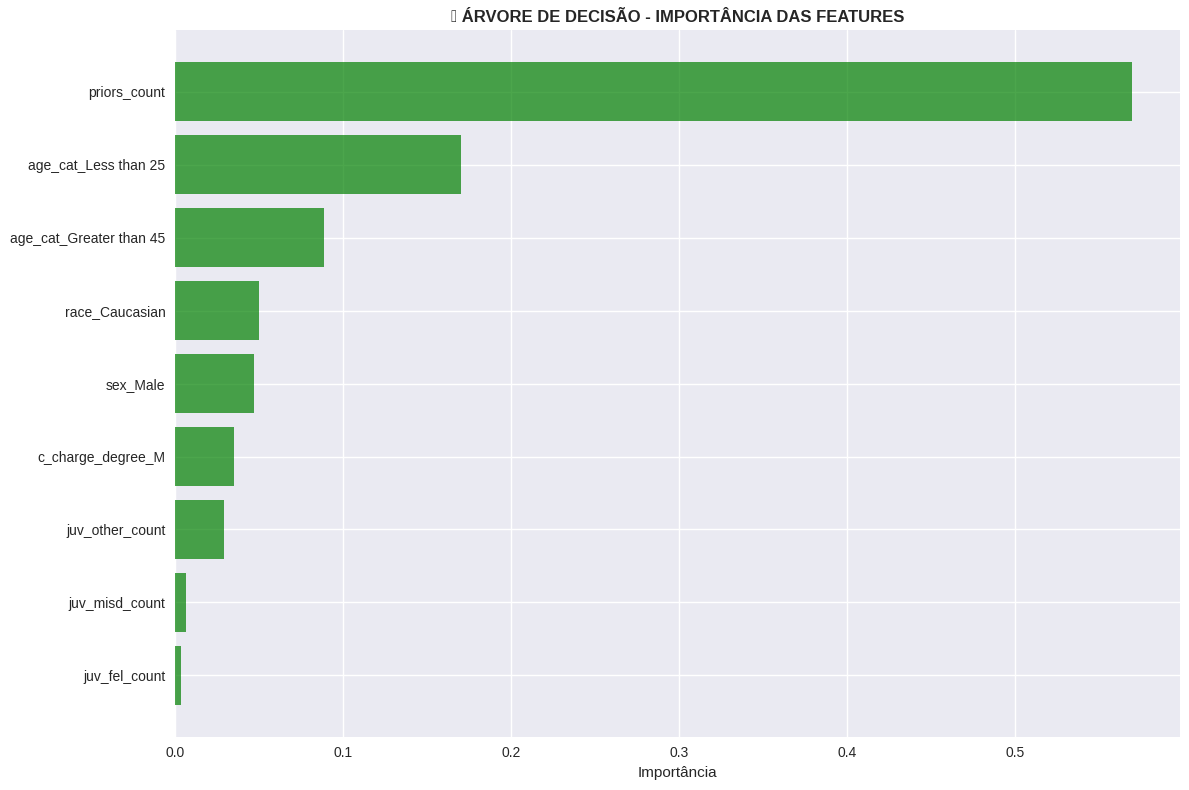

📊 TOP 5 FEATURES MAIS IMPORTANTES:


,feature,importance
0,priors_count,0.569396
7,age_cat_Less than 25,0.170437
6,age_cat_Greater than 45,0.088927
4,race_Caucasian,0.049837
5,sex_Male,0.046907



🎯 ANÁLISE DE THRESHOLDS:


,threshold,accuracy,fpr_aa,fpr_caucasian,fpr_ratio
0,0.3,0.5824,0.7162,0.6094,1.1753
1,0.4,0.6307,0.5611,0.4141,1.3550
2,0.5,0.6581,0.3729,0.2109,1.7680
3,0.6,0.6487,0.2541,0.0625,4.0660
4,0.7,0.6250,0.1617,0.0391,4.1399


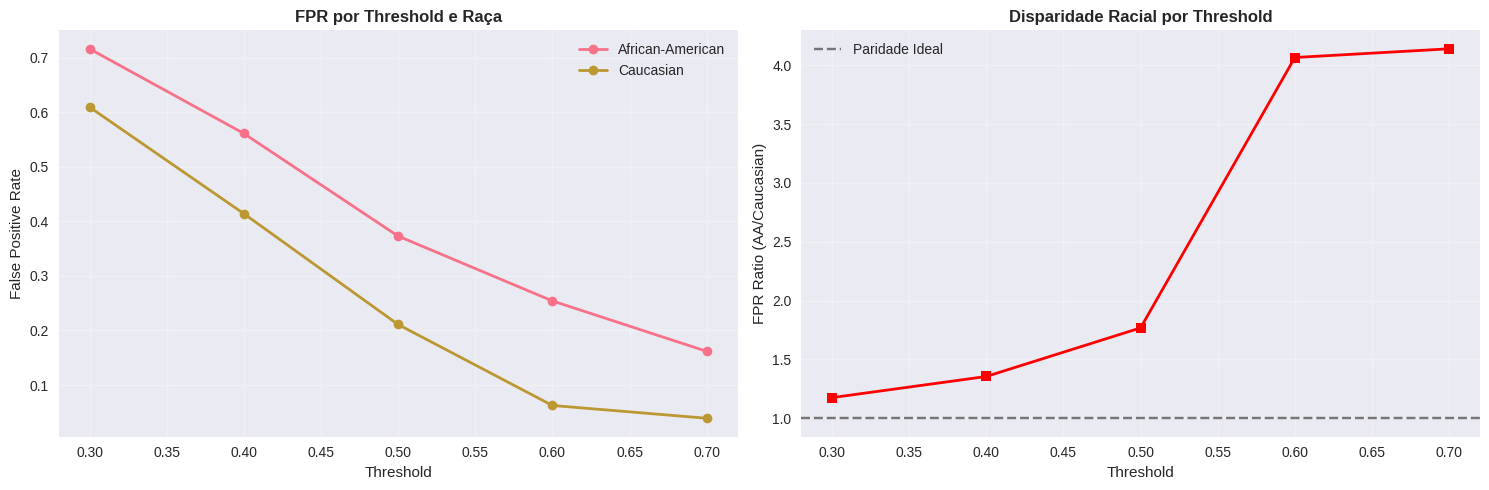

In [8]:
# =============================================================================
# 7. MODELO 2: ÁRVORE DE DECISÃO
# =============================================================================

print("\n🎯 MODELO 2: ÁRVORE DE DECISÃO")
print("=" * 50)

# Pré-processamento específico (sem scaling)
tree_preprocessor = ColumnTransformer([
    ('num', 'passthrough', numerical_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

# Pipeline e treino
tree_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42, max_depth=8, min_samples_split=20,
        min_samples_leaf=10, class_weight='balanced'
    ))
])

print("🤖 TREINANDO MODELO...")
cv_scores_tree = cross_val_score(tree_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
tree_pipeline.fit(X_train, y_train)

# Predições e métricas
y_pred_tree = tree_pipeline.predict(X_test)
y_proba_tree = tree_pipeline.predict_proba(X_test)[:, 1]

tree_auc = roc_auc_score(y_test, y_proba_tree)
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)

print("✅ MÉTRICAS DE PERFORMANCE:")
print(f"   • ROC-AUC: {tree_auc:.4f} (CV: {cv_scores_tree.mean():.4f} ± {cv_scores_tree.std() * 2:.4f})")
print(f"   • Acurácia: {tree_accuracy:.4f}")
print(f"   • F1-Score: {tree_f1:.4f}")

# Análise de fairness
fairness_tree = calcular_metricas_fairness(y_test, y_pred_tree, grupos_raciais_test)
print(f"\n⚖️ MÉTRICAS DE FAIRNESS:")
print(f"   • FPR African-American: {fairness_tree['African-American']['fpr']:.3f}")
print(f"   • FPR Caucasian: {fairness_tree['Caucasian']['fpr']:.3f}")
print(f"   • FPR Ratio: {fairness_tree['disparity_ratio']:.2f}x")

# Feature Importance
tree_model = tree_pipeline.named_steps['classifier']
preprocessor = tree_pipeline.named_steps['preprocessor']
feature_names = numerical_features + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': tree_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
top_importance = importance_df.head(15)
plt.barh(top_importance['feature'], top_importance['importance'], color='green', alpha=0.7)
plt.xlabel('Importância')
plt.title('🌳 ÁRVORE DE DECISÃO - IMPORTÂNCIA DAS FEATURES', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("📊 TOP 5 FEATURES MAIS IMPORTANTES:")
display(importance_df.head(5))

# Análise de thresholds
print("\n🎯 ANÁLISE DE THRESHOLDS:")
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
threshold_results = []

for threshold in thresholds:
    y_pred_thresh = (y_proba_tree >= threshold).astype(int)
    fairness_thresh = calcular_metricas_fairness(y_test, y_pred_thresh, grupos_raciais_test)
    accuracy_thresh = accuracy_score(y_test, y_pred_thresh)

    threshold_results.append({
        'threshold': threshold,
        'accuracy': accuracy_thresh,
        'fpr_aa': fairness_thresh['African-American']['fpr'],
        'fpr_caucasian': fairness_thresh['Caucasian']['fpr'],
        'fpr_ratio': fairness_thresh['disparity_ratio']
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df.round(4))

# Plotar trade-offs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(threshold_df['threshold'], threshold_df['fpr_aa'], marker='o', label='African-American', linewidth=2)
ax1.plot(threshold_df['threshold'], threshold_df['fpr_caucasian'], marker='o', label='Caucasian', linewidth=2)
ax1.set_xlabel('Threshold'); ax1.set_ylabel('False Positive Rate')
ax1.set_title('FPR por Threshold e Raça', fontweight='bold'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(threshold_df['threshold'], threshold_df['fpr_ratio'], marker='s', color='red', linewidth=2)
ax2.axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='Paridade Ideal')
ax2.set_xlabel('Threshold'); ax2.set_ylabel('FPR Ratio (AA/Caucasian)')
ax2.set_title('Disparidade Racial por Threshold', fontweight='bold'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Armazenar resultados
resultados_gerais['Decision Tree'] = {
    'roc_auc': tree_auc, 'accuracy': tree_accuracy, 'f1_score': tree_f1,
    'fpr_aa': fairness_tree['African-American']['fpr'],
    'fpr_caucasian': fairness_tree['Caucasian']['fpr'],
    'fpr_ratio': fairness_tree['disparity_ratio'], 'cv_mean': cv_scores_tree.mean(),
    'cv_std': cv_scores_tree.std(), 'model': tree_pipeline,
    'feature_importance': importance_df, 'threshold_analysis': threshold_df,
    'depth': tree_model.get_depth(), 'n_leaves': tree_model.get_n_leaves()
}


🎯 MODELO 3: RANDOM FOREST
🤖 TREINANDO MODELO...
✅ MÉTRICAS DE PERFORMANCE:
   • ROC-AUC: 0.7103 (CV: 0.7231 ± 0.0298)
   • Acurácia: 0.6676
   • F1-Score: 0.6325

⚖️ MÉTRICAS DE FAIRNESS:
   • FPR African-American: 0.360
   • FPR Caucasian: 0.184
   • FPR Ratio: 1.96x


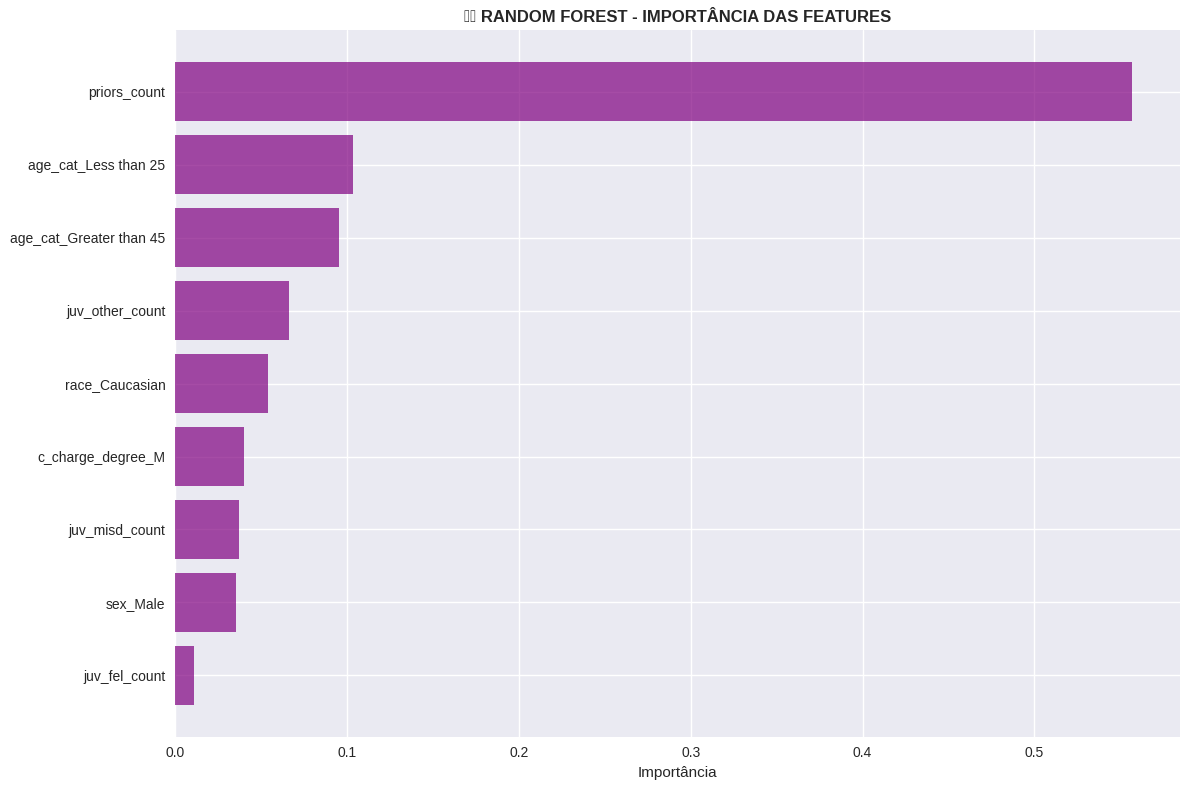

📊 TOP 5 FEATURES MAIS IMPORTANTES:


,feature,importance
0,priors_count,0.556820
7,age_cat_Less than 25,0.103431
6,age_cat_Greater than 45,0.095520
3,juv_other_count,0.066310
4,race_Caucasian,0.054053



📊 ANÁLISE DE ESTABILIDADE ENTRE ÁRVORES:


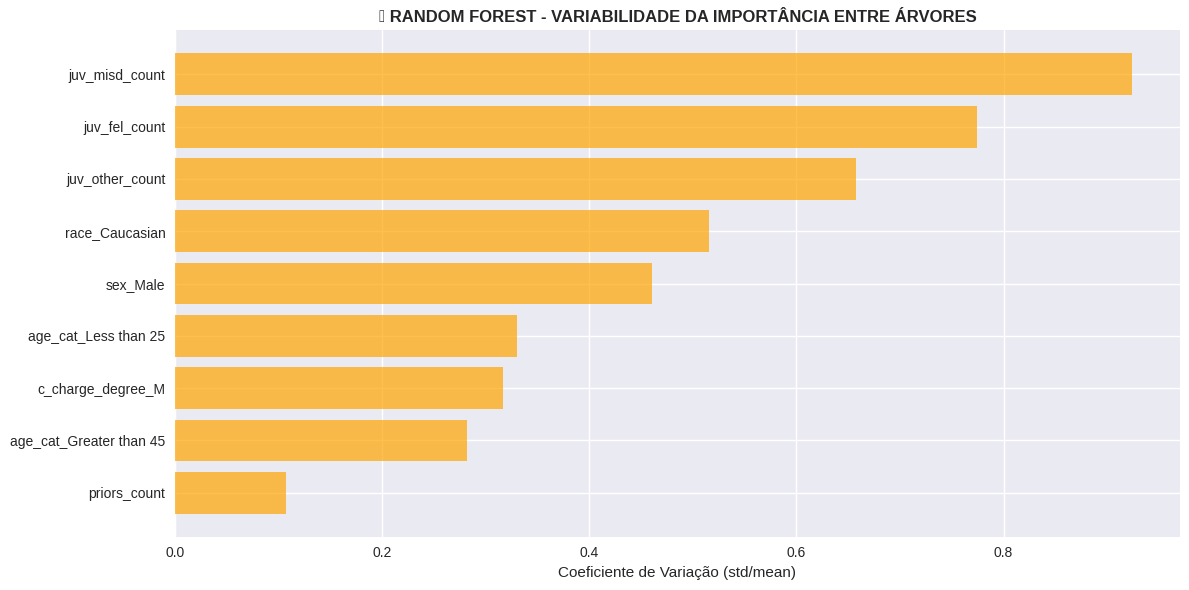

📈 FEATURES COM MAIOR VARIABILIDADE (menos consistentes):


,0
juv_misd_count,0.924089
juv_fel_count,0.774525
juv_other_count,0.657369
race_Caucasian,0.515731
sex_Male,0.460097
age_cat_Less than 25,0.330690


In [9]:
# =============================================================================
# 8. MODELO 3: RANDOM FOREST
# =============================================================================

print("\n🎯 MODELO 3: RANDOM FOREST")
print("=" * 50)

# Pré-processamento específico (sem scaling)
rf_preprocessor = ColumnTransformer([
    ('num', 'passthrough', numerical_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

# Pipeline e treino
rf_pipeline = Pipeline([
    ('preprocessor', rf_preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42, n_estimators=100, max_depth=10,
        min_samples_split=20, min_samples_leaf=10, class_weight='balanced', n_jobs=-1
    ))
])

print("🤖 TREINANDO MODELO...")
cv_scores_rf = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
rf_pipeline.fit(X_train, y_train)

# Predições e métricas
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

rf_auc = roc_auc_score(y_test, y_proba_rf)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("✅ MÉTRICAS DE PERFORMANCE:")
print(f"   • ROC-AUC: {rf_auc:.4f} (CV: {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std() * 2:.4f})")
print(f"   • Acurácia: {rf_accuracy:.4f}")
print(f"   • F1-Score: {rf_f1:.4f}")

# Análise de fairness
fairness_rf = calcular_metricas_fairness(y_test, y_pred_rf, grupos_raciais_test)
print(f"\n⚖️ MÉTRICAS DE FAIRNESS:")
print(f"   • FPR African-American: {fairness_rf['African-American']['fpr']:.3f}")
print(f"   • FPR Caucasian: {fairness_rf['Caucasian']['fpr']:.3f}")
print(f"   • FPR Ratio: {fairness_rf['disparity_ratio']:.2f}x")

# Feature Importance
rf_model = rf_pipeline.named_steps['classifier']
preprocessor = rf_pipeline.named_steps['preprocessor']
feature_names = numerical_features + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))

rf_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
top_rf_importance = rf_importance_df.head(15)
plt.barh(top_rf_importance['feature'], top_rf_importance['importance'], color='purple', alpha=0.7)
plt.xlabel('Importância')
plt.title('🌳🌳 RANDOM FOREST - IMPORTÂNCIA DAS FEATURES', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("📊 TOP 5 FEATURES MAIS IMPORTANTES:")
display(rf_importance_df.head(5))

# Análise de estabilidade entre árvores
print("\n📊 ANÁLISE DE ESTABILIDADE ENTRE ÁRVORES:")
importances_por_arvore = []
for i, tree in enumerate(rf_model.estimators_[:10]):  # Primeiras 10 árvores
    importances_por_arvore.append(tree.feature_importances_)

importances_stability = pd.DataFrame(importances_por_arvore, columns=feature_names)
stability_std = importances_stability.std() / importances_stability.mean()
stability_std = stability_std.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
top_stability = stability_std.head(12)
plt.barh(top_stability.index, top_stability.values, color='orange', alpha=0.7)
plt.xlabel('Coeficiente de Variação (std/mean)')
plt.title('🔍 RANDOM FOREST - VARIABILIDADE DA IMPORTÂNCIA ENTRE ÁRVORES', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("📈 FEATURES COM MAIOR VARIABILIDADE (menos consistentes):")
display(stability_std.head(6))

# Armazenar resultados
resultados_gerais['Random Forest'] = {
    'roc_auc': rf_auc, 'accuracy': rf_accuracy, 'f1_score': rf_f1,
    'fpr_aa': fairness_rf['African-American']['fpr'],
    'fpr_caucasian': fairness_rf['Caucasian']['fpr'],
    'fpr_ratio': fairness_rf['disparity_ratio'], 'cv_mean': cv_scores_rf.mean(),
    'cv_std': cv_scores_rf.std(), 'model': rf_pipeline,
    'feature_importance': rf_importance_df, 'feature_stability': stability_std,
    'n_estimators': rf_model.n_estimators, 'max_depth': rf_model.max_depth
}


🎯 MODELO 4: XGBOOST
🤖 TREINANDO MODELO...
✅ MÉTRICAS DE PERFORMANCE:
   • ROC-AUC: 0.6976 (CV: 0.7147 ± 0.0322)
   • Acurácia: 0.6581
   • F1-Score: 0.5957

⚖️ MÉTRICAS DE FAIRNESS:
   • FPR African-American: 0.310
   • FPR Caucasian: 0.141
   • FPR Ratio: 2.21x


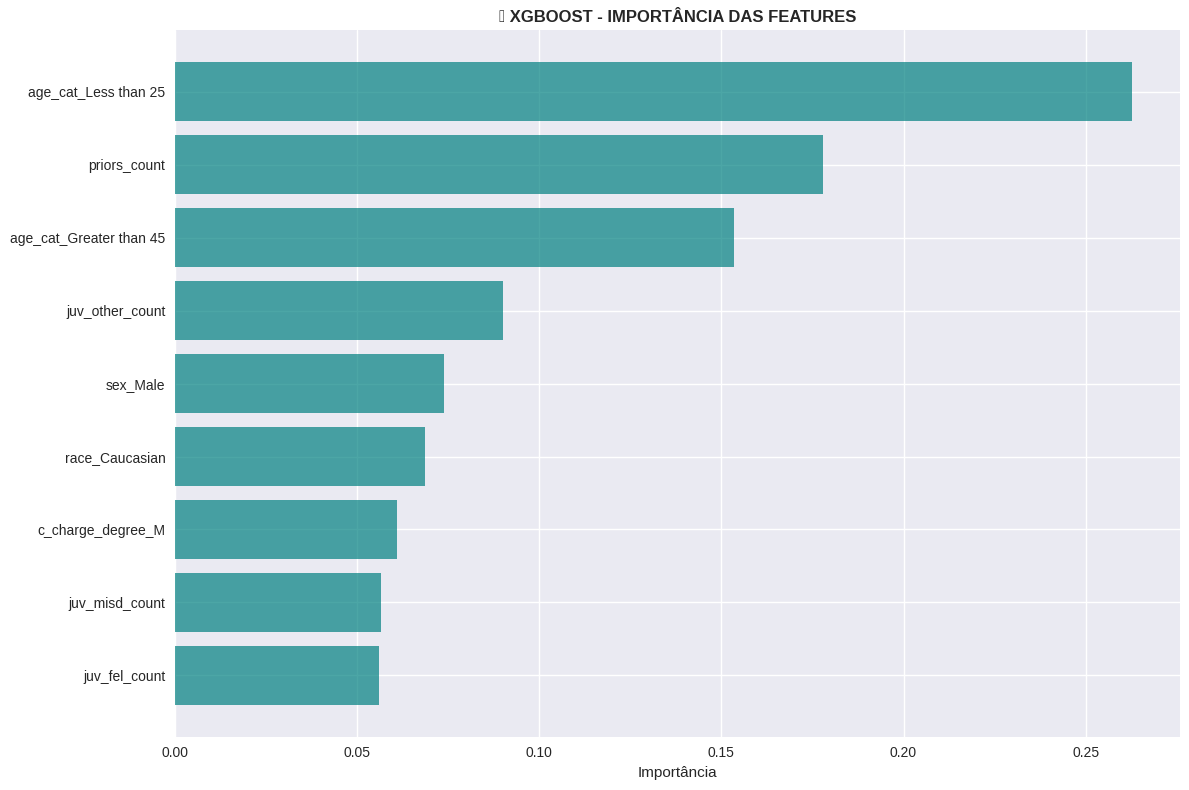

📊 TOP 5 FEATURES MAIS IMPORTANTES:


,feature,importance
7,age_cat_Less than 25,0.262759
0,priors_count,0.177867
6,age_cat_Greater than 45,0.153464
3,juv_other_count,0.090133
5,sex_Male,0.073720



📈 ANÁLISE DE GANHO ACUMULADO:


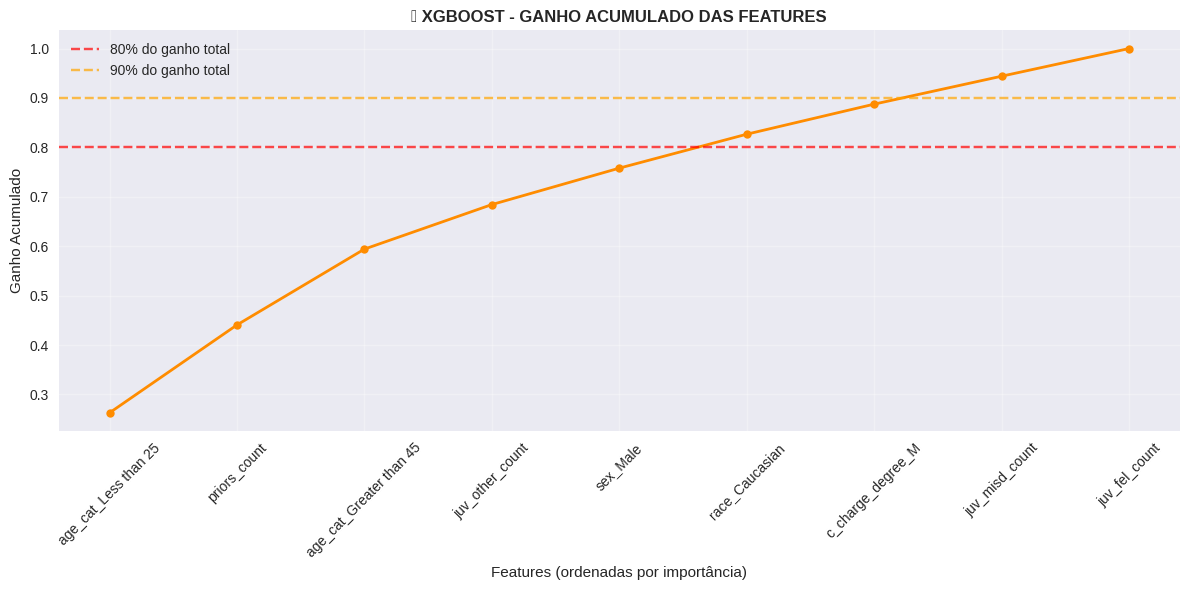

🔍 FEATURES PARA GANHO ACUMULADO:
   • 80% do ganho: 5 features
   • 90% do ganho: 7 features


In [10]:
# =============================================================================
# 9. MODELO 4: XGBOOST
# =============================================================================

print("\n🎯 MODELO 4: XGBOOST")
print("=" * 50)

# Pré-processamento específico (sem scaling)
xgb_preprocessor = ColumnTransformer([
    ('num', 'passthrough', numerical_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

# Pipeline e treino
xgb_pipeline = Pipeline([
    ('preprocessor', xgb_preprocessor),
    ('classifier', XGBClassifier(
        random_state=42, n_estimators=100, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', use_label_encoder=False
    ))
])

print("🤖 TREINANDO MODELO...")
cv_scores_xgb = cross_val_score(xgb_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
xgb_pipeline.fit(X_train, y_train)

# Predições e métricas
y_pred_xgb = xgb_pipeline.predict(X_test)
y_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

xgb_auc = roc_auc_score(y_test, y_proba_xgb)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

print("✅ MÉTRICAS DE PERFORMANCE:")
print(f"   • ROC-AUC: {xgb_auc:.4f} (CV: {cv_scores_xgb.mean():.4f} ± {cv_scores_xgb.std() * 2:.4f})")
print(f"   • Acurácia: {xgb_accuracy:.4f}")
print(f"   • F1-Score: {xgb_f1:.4f}")

# Análise de fairness
fairness_xgb = calcular_metricas_fairness(y_test, y_pred_xgb, grupos_raciais_test)
print(f"\n⚖️ MÉTRICAS DE FAIRNESS:")
print(f"   • FPR African-American: {fairness_xgb['African-American']['fpr']:.3f}")
print(f"   • FPR Caucasian: {fairness_xgb['Caucasian']['fpr']:.3f}")
print(f"   • FPR Ratio: {fairness_xgb['disparity_ratio']:.2f}x")

# Feature Importance
xgb_model = xgb_pipeline.named_steps['classifier']
preprocessor = xgb_pipeline.named_steps['preprocessor']
feature_names = numerical_features + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))

xgb_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
top_xgb_importance = xgb_importance_df.head(15)
plt.barh(top_xgb_importance['feature'], top_xgb_importance['importance'], color='teal', alpha=0.7)
plt.xlabel('Importância')
plt.title('🚀 XGBOOST - IMPORTÂNCIA DAS FEATURES', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("📊 TOP 5 FEATURES MAIS IMPORTANTES:")
display(xgb_importance_df.head(5))

# Análise de ganho acumulado
print("\n📈 ANÁLISE DE GANHO ACUMULADO:")
xgb_importance_df['cumulative_importance'] = xgb_importance_df['importance'].cumsum()

plt.figure(figsize=(12, 6))
plt.plot(xgb_importance_df['feature'][:15], xgb_importance_df['cumulative_importance'][:15],
         marker='o', linewidth=2, markersize=6, color='darkorange')
plt.axhline(y=0.8, color='red', linestyle='--', alpha=0.7, label='80% do ganho total')
plt.axhline(y=0.9, color='orange', linestyle='--', alpha=0.7, label='90% do ganho total')
plt.xlabel('Features (ordenadas por importância)')
plt.ylabel('Ganho Acumulado')
plt.title('📊 XGBOOST - GANHO ACUMULADO DAS FEATURES', fontweight='bold')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n_features_80 = len(xgb_importance_df[xgb_importance_df['cumulative_importance'] <= 0.8])
n_features_90 = len(xgb_importance_df[xgb_importance_df['cumulative_importance'] <= 0.9])
print(f"🔍 FEATURES PARA GANHO ACUMULADO:")
print(f"   • 80% do ganho: {n_features_80} features")
print(f"   • 90% do ganho: {n_features_90} features")

# Armazenar resultados
resultados_gerais['XGBoost'] = {
    'roc_auc': xgb_auc, 'accuracy': xgb_accuracy, 'f1_score': xgb_f1,
    'fpr_aa': fairness_xgb['African-American']['fpr'],
    'fpr_caucasian': fairness_xgb['Caucasian']['fpr'],
    'fpr_ratio': fairness_xgb['disparity_ratio'], 'cv_mean': cv_scores_xgb.mean(),
    'cv_std': cv_scores_xgb.std(), 'model': xgb_pipeline,
    'feature_importance': xgb_importance_df, 'cumulative_gain': xgb_importance_df,
    'n_estimators': xgb_model.n_estimators, 'learning_rate': xgb_model.learning_rate
}


🎯 MODELO 5: K-NEAREST NEIGHBORS
🤖 TREINANDO MODELO...
✅ MÉTRICAS DE PERFORMANCE:
   • ROC-AUC: 0.6651 (CV: 0.6892 ± 0.0339)
   • Acurácia: 0.6316
   • F1-Score: 0.5730

⚖️ MÉTRICAS DE FAIRNESS:
   • FPR African-American: 0.373
   • FPR Caucasian: 0.156
   • FPR Ratio: 2.39x

👥 ANÁLISE DA COMPOSIÇÃO RACIAL DAS VIZINHANÇAS:


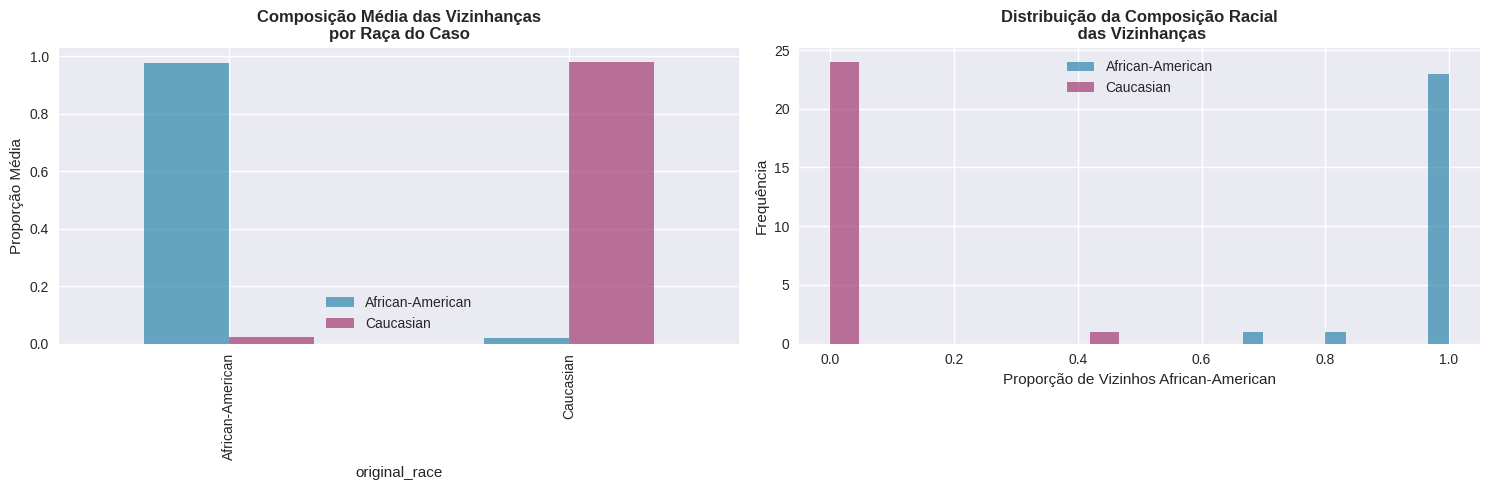

📊 ESTATÍSTICAS DAS VIZINHANÇAS:
   • Casos African-American: 25
   • Casos Caucasian: 25
   • Proporção média AA em vizinhanças de AA: 0.979
   • Proporção média AA em vizinhanças de Caucasian: 0.019


In [11]:
# =============================================================================
# 10. MODELO 5: K-NEAREST NEIGHBORS
# =============================================================================

print("\n🎯 MODELO 5: K-NEAREST NEIGHBORS")
print("=" * 50)

# Pré-processamento específico (COM scaling - essencial para KNN)
knn_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

# Pipeline e treino
knn_pipeline = Pipeline([
    ('preprocessor', knn_preprocessor),
    ('classifier', KNeighborsClassifier(
        n_neighbors=15, weights='distance', metric='minkowski'
    ))
])

print("🤖 TREINANDO MODELO...")
cv_scores_knn = cross_val_score(knn_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
knn_pipeline.fit(X_train, y_train)

# Predições e métricas
y_pred_knn = knn_pipeline.predict(X_test)
y_proba_knn = knn_pipeline.predict_proba(X_test)[:, 1]

knn_auc = roc_auc_score(y_test, y_proba_knn)
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

print("✅ MÉTRICAS DE PERFORMANCE:")
print(f"   • ROC-AUC: {knn_auc:.4f} (CV: {cv_scores_knn.mean():.4f} ± {cv_scores_knn.std() * 2:.4f})")
print(f"   • Acurácia: {knn_accuracy:.4f}")
print(f"   • F1-Score: {knn_f1:.4f}")

# Análise de fairness
fairness_knn = calcular_metricas_fairness(y_test, y_pred_knn, grupos_raciais_test)
print(f"\n⚖️ MÉTRICAS DE FAIRNESS:")
print(f"   • FPR African-American: {fairness_knn['African-American']['fpr']:.3f}")
print(f"   • FPR Caucasian: {fairness_knn['Caucasian']['fpr']:.3f}")
print(f"   • FPR Ratio: {fairness_knn['disparity_ratio']:.2f}x")

# KNN não tem feature importance, mas podemos analisar composição das vizinhanças
print("\n👥 ANÁLISE DA COMPOSIÇÃO RACIAL DAS VIZINHANÇAS:")
knn_model = knn_pipeline.named_steps['classifier']
preprocessor_fitted = knn_pipeline.named_steps['preprocessor']
X_test_processed = preprocessor_fitted.transform(X_test)

# Amostra de casos para análise
sample_indices = np.random.choice(len(X_test), size=min(50, len(X_test)), replace=False)
racial_composition = []

for idx in sample_indices:
    distances, indices = knn_model.kneighbors(X_test_processed[idx].reshape(1, -1))
    neighbor_races = X_train.iloc[indices[0]]['race'].value_counts(normalize=True)
    racial_composition.append({
        'aa_proportion': neighbor_races.get('African-American', 0),
        'caucasian_proportion': neighbor_races.get('Caucasian', 0),
        'original_race': X_test.iloc[idx]['race']
    })

racial_df = pd.DataFrame(racial_composition)

# Plotar composição racial
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

composition_by_race = racial_df.groupby('original_race')[['aa_proportion', 'caucasian_proportion']].mean()
composition_by_race.plot(kind='bar', ax=ax1, color=['#2E86AB', '#A23B72'], alpha=0.7)
ax1.set_title('Composição Média das Vizinhanças\npor Raça do Caso', fontweight='bold')
ax1.set_ylabel('Proporção Média')
ax1.legend(['African-American', 'Caucasian'])

racial_df[racial_df['original_race'] == 'African-American']['aa_proportion'].hist(
    ax=ax2, alpha=0.7, label='African-American', bins=10, color='#2E86AB'
)
racial_df[racial_df['original_race'] == 'Caucasian']['aa_proportion'].hist(
    ax=ax2, alpha=0.7, label='Caucasian', bins=10, color='#A23B72'
)
ax2.set_xlabel('Proporção de Vizinhos African-American')
ax2.set_ylabel('Frequência')
ax2.set_title('Distribuição da Composição Racial\n das Vizinhanças', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

print("📊 ESTATÍSTICAS DAS VIZINHANÇAS:")
print(f"   • Casos African-American: {len(racial_df[racial_df['original_race'] == 'African-American'])}")
print(f"   • Casos Caucasian: {len(racial_df[racial_df['original_race'] == 'Caucasian'])}")
print(f"   • Proporção média AA em vizinhanças de AA: {racial_df[racial_df['original_race'] == 'African-American']['aa_proportion'].mean():.3f}")
print(f"   • Proporção média AA em vizinhanças de Caucasian: {racial_df[racial_df['original_race'] == 'Caucasian']['aa_proportion'].mean():.3f}")

# Armazenar resultados
resultados_gerais['KNN'] = {
    'roc_auc': knn_auc, 'accuracy': knn_accuracy, 'f1_score': knn_f1,
    'fpr_aa': fairness_knn['African-American']['fpr'],
    'fpr_caucasian': fairness_knn['Caucasian']['fpr'],
    'fpr_ratio': fairness_knn['disparity_ratio'], 'cv_mean': cv_scores_knn.mean(),
    'cv_std': cv_scores_knn.std(), 'model': knn_pipeline,
    'neighborhood_analysis': racial_df, 'n_neighbors': knn_model.n_neighbors
}


🎯 MODELO 6: REDE NEURAL
🤖 TREINANDO MODELO...
✅ MÉTRICAS DE PERFORMANCE:
   • ROC-AUC: 0.7102 (CV: 0.7248 ± 0.0452)
   • Acurácia: 0.6667
   • F1-Score: 0.6140

⚖️ MÉTRICAS DE FAIRNESS:
   • FPR African-American: 0.333
   • FPR Caucasian: 0.133
   • FPR Ratio: 2.51x

📈 ANÁLISE DO TREINAMENTO DA REDE NEURAL:


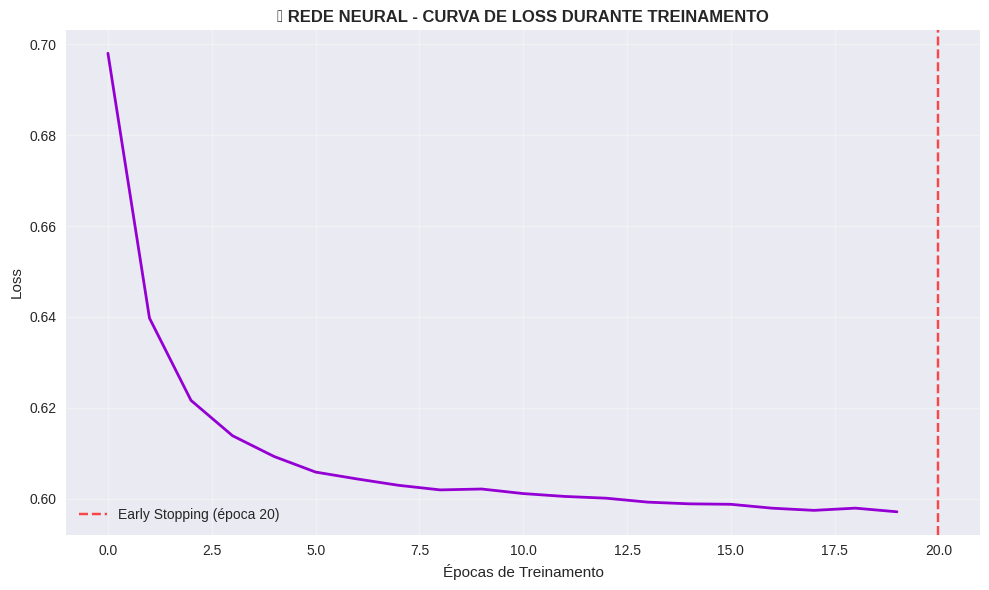

🔍 INFORMAÇÕES DA REDE NEURAL:
   • Épocas de treinamento: 20
   • Arquitetura: (50, 25)
   • Total de neurônios: 75
   • Função de ativação: relu
   • Otimizador: adam

⚠️  Rede Neural não possui feature importance nativa
   (Para análise detalhada, seria necessário Permutation Importance)

✅ TODOS OS 6 MODELOS TREINADOS E AVALIADOS!


In [12]:
# =============================================================================
# 11. MODELO 6: REDE NEURAL
# =============================================================================

print("\n🎯 MODELO 6: REDE NEURAL")
print("=" * 50)

# Pré-processamento específico (COM scaling - essencial para redes neurais)
mlp_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

# Pipeline e treino
mlp_pipeline = Pipeline([
    ('preprocessor', mlp_preprocessor),
    ('classifier', MLPClassifier(
        random_state=42, hidden_layer_sizes=(50, 25), activation='relu', solver='adam',
        alpha=0.001, learning_rate='adaptive', max_iter=500,
        early_stopping=True, validation_fraction=0.1
    ))
])

print("🤖 TREINANDO MODELO...")
cv_scores_mlp = cross_val_score(mlp_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
mlp_pipeline.fit(X_train, y_train)

# Predições e métricas
y_pred_mlp = mlp_pipeline.predict(X_test)
y_proba_mlp = mlp_pipeline.predict_proba(X_test)[:, 1]

mlp_auc = roc_auc_score(y_test, y_proba_mlp)
mlp_accuracy = accuracy_score(y_test, y_pred_mlp)
mlp_f1 = f1_score(y_test, y_pred_mlp)

print("✅ MÉTRICAS DE PERFORMANCE:")
print(f"   • ROC-AUC: {mlp_auc:.4f} (CV: {cv_scores_mlp.mean():.4f} ± {cv_scores_mlp.std() * 2:.4f})")
print(f"   • Acurácia: {mlp_accuracy:.4f}")
print(f"   • F1-Score: {mlp_f1:.4f}")

# Análise de fairness
fairness_mlp = calcular_metricas_fairness(y_test, y_pred_mlp, grupos_raciais_test)
print(f"\n⚖️ MÉTRICAS DE FAIRNESS:")
print(f"   • FPR African-American: {fairness_mlp['African-American']['fpr']:.3f}")
print(f"   • FPR Caucasian: {fairness_mlp['Caucasian']['fpr']:.3f}")
print(f"   • FPR Ratio: {fairness_mlp['disparity_ratio']:.2f}x")

# Análise da curva de treinamento
mlp_model = mlp_pipeline.named_steps['classifier']
print("\n📈 ANÁLISE DO TREINAMENTO DA REDE NEURAL:")

plt.figure(figsize=(10, 6))
if hasattr(mlp_model, 'loss_curve_'):
    plt.plot(mlp_model.loss_curve_, linewidth=2, color='darkviolet')
    plt.xlabel('Épocas de Treinamento')
    plt.ylabel('Loss')
    plt.title('📊 REDE NEURAL - CURVA DE LOSS DURANTE TREINAMENTO', fontweight='bold')
    plt.grid(True, alpha=0.3)

    if mlp_model.n_iter_ < mlp_model.max_iter:
        plt.axvline(x=mlp_model.n_iter_, color='red', linestyle='--',
                   alpha=0.7, label=f'Early Stopping (época {mlp_model.n_iter_})')
        plt.legend()
else:
    plt.text(0.5, 0.5, 'Curva de loss não disponível\n(early stopping pode ter impedido armazenamento)',
             ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
    plt.title('Curva de Loss - Não Disponível', fontweight='bold')

plt.tight_layout()
plt.show()

print("🔍 INFORMAÇÕES DA REDE NEURAL:")
print(f"   • Épocas de treinamento: {mlp_model.n_iter_}")
print(f"   • Arquitetura: {mlp_model.hidden_layer_sizes}")
print(f"   • Total de neurônios: {sum(mlp_model.hidden_layer_sizes)}")
print(f"   • Função de ativação: {mlp_model.activation}")
print(f"   • Otimizador: {mlp_model.solver}")

# Rede neural não tem feature importance nativa, mas podemos usar permutação para estimar
print("\n⚠️  Rede Neural não possui feature importance nativa")
print("   (Para análise detalhada, seria necessário Permutation Importance)")

# Armazenar resultados
resultados_gerais['Neural Network'] = {
    'roc_auc': mlp_auc, 'accuracy': mlp_accuracy, 'f1_score': mlp_f1,
    'fpr_aa': fairness_mlp['African-American']['fpr'],
    'fpr_caucasian': fairness_mlp['Caucasian']['fpr'],
    'fpr_ratio': fairness_mlp['disparity_ratio'], 'cv_mean': cv_scores_mlp.mean(),
    'cv_std': cv_scores_mlp.std(), 'model': mlp_pipeline,
    'n_iter': mlp_model.n_iter_, 'architecture': mlp_model.hidden_layer_sizes
}

print(f"\n✅ TODOS OS 6 MODELOS TREINADOS E AVALIADOS!")

🎯 ANÁLISE COMPARATIVA FINAL - TODOS OS MODELOS
📊 COMPARAÇÃO DAS CURVAS ROC


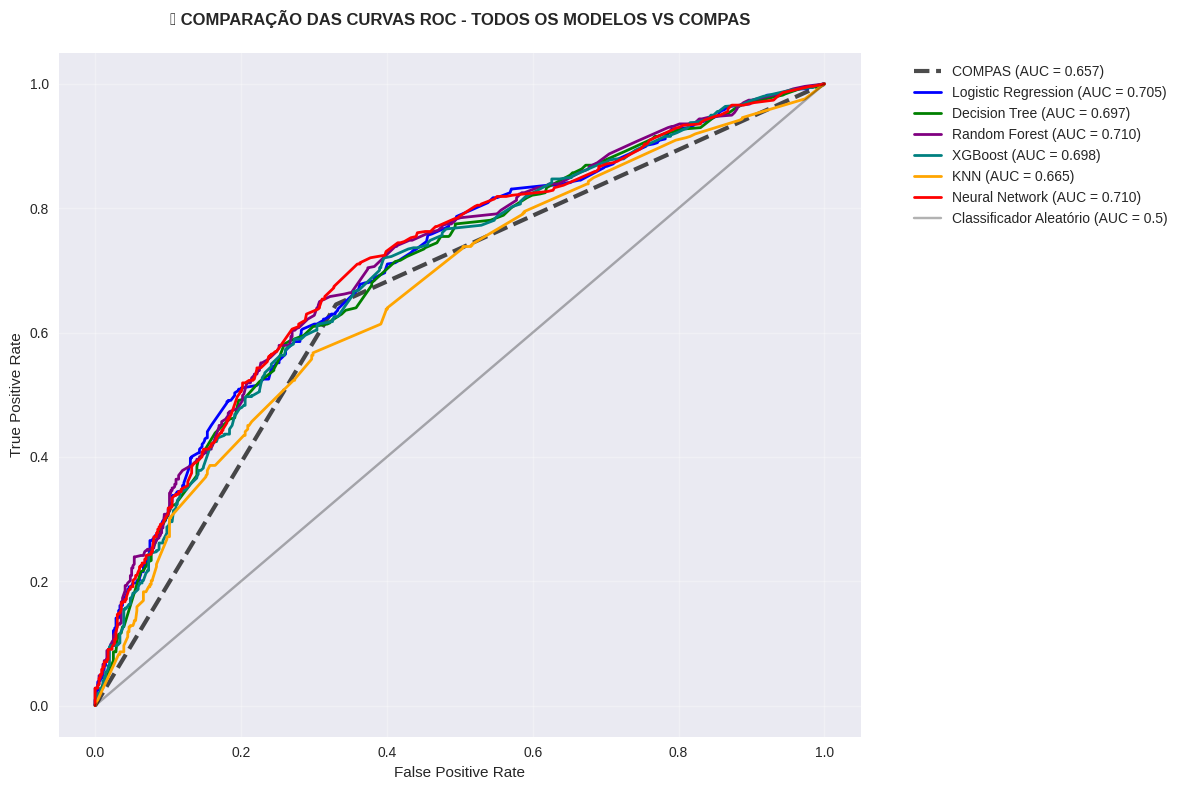

In [13]:
# =============================================================================
# 12. ANÁLISE COMPARATIVA FINAL - TODOS OS MODELOS VS COMPAS
# =============================================================================

print("🎯 ANÁLISE COMPARATIVA FINAL - TODOS OS MODELOS")
print("=" * 70)

# =============================================================================
# 12.1 CURVAS ROC COMPARATIVAS
# =============================================================================

print("📊 COMPARAÇÃO DAS CURVAS ROC")

plt.figure(figsize=(12, 8))

# Plotar COMPAS primeiro
compas_probs = (df_principal['score_text'].isin(['High', 'Medium'])).astype(int)
fpr_compas, tpr_compas, _ = roc_curve(y, compas_probs)
auc_compas = roc_auc_score(y, compas_probs)
plt.plot(fpr_compas, tpr_compas, 'k--', linewidth=3, alpha=0.7,
         label=f'COMPAS (AUC = {auc_compas:.3f})')

# Cores para os modelos
colors = ['blue', 'green', 'purple', 'teal', 'orange', 'red']
model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest',
               'XGBoost', 'KNN', 'Neural Network']

# Plotar cada modelo
for i, (name, color) in enumerate(zip(model_names, colors)):
    if name in resultados_gerais:
        model = resultados_gerais[name]['model']
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            auc_score = roc_auc_score(y_test, y_proba)
            plt.plot(fpr, tpr, color=color, linewidth=2,
                    label=f'{name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k-', alpha=0.3, label='Classificador Aleatório (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('📈 COMPARAÇÃO DAS CURVAS ROC - TODOS OS MODELOS VS COMPAS', fontweight='bold', pad=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

🏆 COMPARAÇÃO DE PERFORMANCE (ROC-AUC)
📊 TABELA COMPARATIVA COMPLETA:


,Modelo,ROC-AUC,Acurácia,F1-Score,FPR African-American,FPR Caucasian,FPR Ratio,CV Mean,CV Std,Melhoria AUC vs COMPAS,Melhoria Fairness vs COMPAS
0,COMPAS,0.6575,0.6582,0.6398,0.4234,0.2201,1.9232,N/A,N/A,0.0000,0.0000
1,Logistic Regression,0.7052,0.6619,0.6254,0.3828,0.1641,2.3335,0.723115,0.016752,0.0477,-0.4103
2,Decision Tree,0.6973,0.6581,0.6267,0.3729,0.2109,1.7680,0.711132,0.014029,0.0398,0.1552
3,Random Forest,0.7103,0.6676,0.6325,0.3597,0.1836,1.9594,0.723125,0.014876,0.0528,-0.0362
4,XGBoost,0.6976,0.6581,0.5957,0.3102,0.1406,2.2061,0.714684,0.016092,0.0401,-0.2829
5,KNN,0.6651,0.6316,0.5730,0.3729,0.1562,2.3868,0.6892,0.016949,0.0076,-0.4636
6,Neural Network,0.7102,0.6667,0.6140,0.3333,0.1328,2.5098,0.724818,0.022584,0.0527,-0.5866


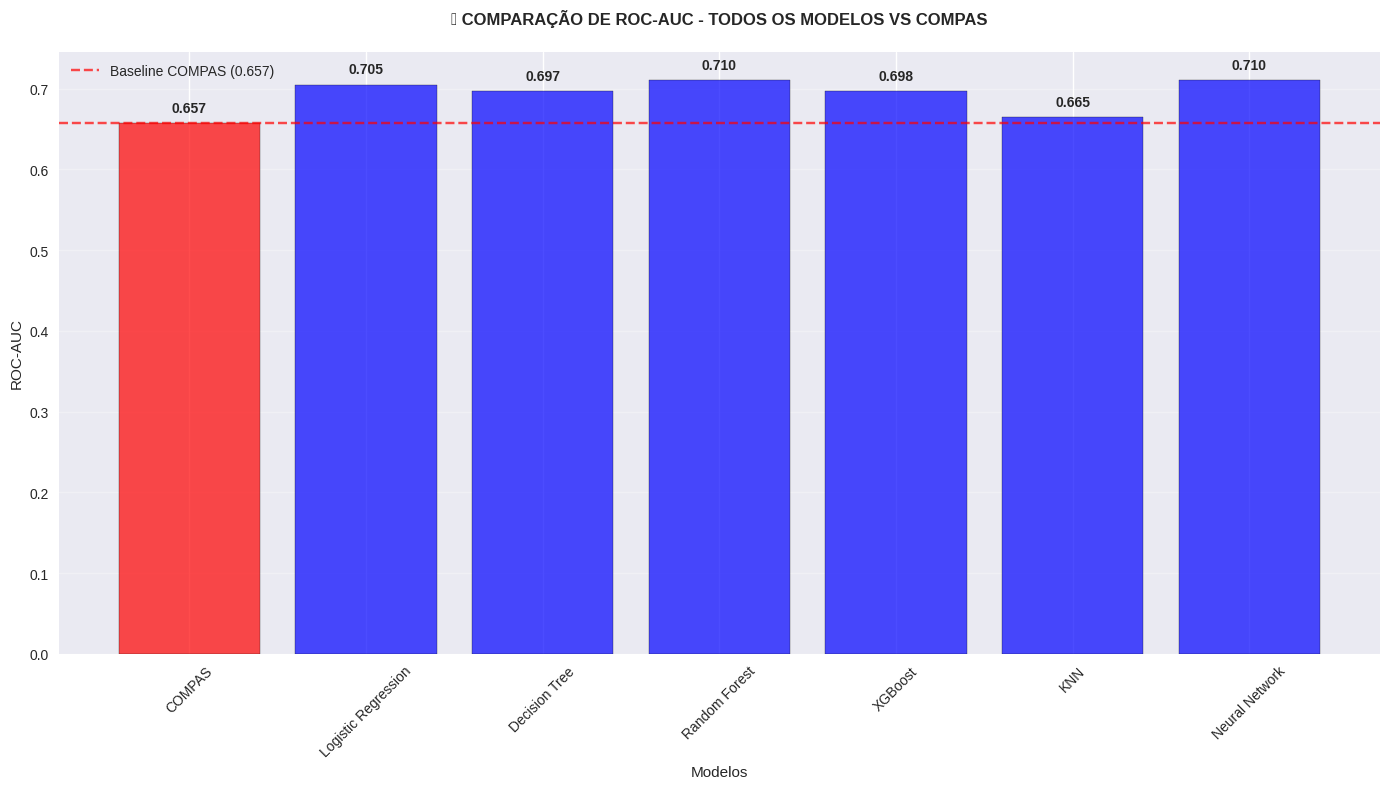

In [14]:
# =============================================================================
# 12.2 COMPARAÇÃO DE PERFORMANCE (ROC-AUC) - CORRIGIDO
# =============================================================================

print("🏆 COMPARAÇÃO DE PERFORMANCE (ROC-AUC)")

# Primeiro, garantir que o COMPAS está nos resultados
if 'COMPAS' not in resultados_gerais:
    # Calcular métricas do COMPAS
    compas_predictions = (df_principal['score_text'].isin(['High', 'Medium'])).astype(int)
    compas_fairness = calcular_metricas_fairness(y, compas_predictions, df_principal['race'])

    resultados_gerais['COMPAS'] = {
        'roc_auc': roc_auc_score(y, compas_predictions),
        'accuracy': accuracy_score(y, compas_predictions),
        'f1_score': f1_score(y, compas_predictions),
        'fpr_aa': compas_fairness['African-American']['fpr'],
        'fpr_caucasian': compas_fairness['Caucasian']['fpr'],
        'fpr_ratio': compas_fairness['disparity_ratio'],
        'cv_mean': 'N/A',
        'cv_std': 'N/A'
    }

# Agora criar DataFrame comparativo
modelos_comparar = ['COMPAS'] + [m for m in resultados_gerais.keys() if m != 'COMPAS']
dados_comparativos = []

for modelo in modelos_comparar:
    dados = resultados_gerais[modelo]
    dados_comparativos.append({
        'Modelo': modelo,
        'ROC-AUC': dados['roc_auc'],
        'Acurácia': dados['accuracy'],
        'F1-Score': dados['f1_score'],
        'FPR African-American': dados['fpr_aa'],
        'FPR Caucasian': dados['fpr_caucasian'],
        'FPR Ratio': dados['fpr_ratio'],
        'CV Mean': dados.get('cv_mean', 'N/A'),
        'CV Std': dados.get('cv_std', 'N/A')
    })

df_comparativo = pd.DataFrame(dados_comparativos)

# Calcular melhorias vs COMPAS
compas_auc = resultados_gerais['COMPAS']['roc_auc']
compas_fpr_ratio = resultados_gerais['COMPAS']['fpr_ratio']

df_comparativo['Melhoria AUC vs COMPAS'] = df_comparativo['ROC-AUC'] - compas_auc
df_comparativo['Melhoria Fairness vs COMPAS'] = compas_fpr_ratio - df_comparativo['FPR Ratio']

print("📊 TABELA COMPARATIVA COMPLETA:")
display(df_comparativo.round(4))

# Plotar comparação de ROC-AUC
plt.figure(figsize=(14, 8))
modelos_plot = df_comparativo['Modelo']
auc_values = df_comparativo['ROC-AUC']

colors_auc = ['red' if 'COMPAS' in model else 'blue' for model in modelos_plot]
bars = plt.bar(modelos_plot, auc_values, color=colors_auc, alpha=0.7, edgecolor='black')

plt.axhline(y=compas_auc, color='red', linestyle='--', alpha=0.7,
           label=f'Baseline COMPAS ({compas_auc:.3f})')
plt.xlabel('Modelos')
plt.ylabel('ROC-AUC')
plt.title('🏆 COMPARAÇÃO DE ROC-AUC - TODOS OS MODELOS VS COMPAS', fontweight='bold', pad=20)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for bar, valor in zip(bars, auc_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{valor:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

⚖️ COMPARAÇÃO DE FAIRNESS (FPR RATIO)


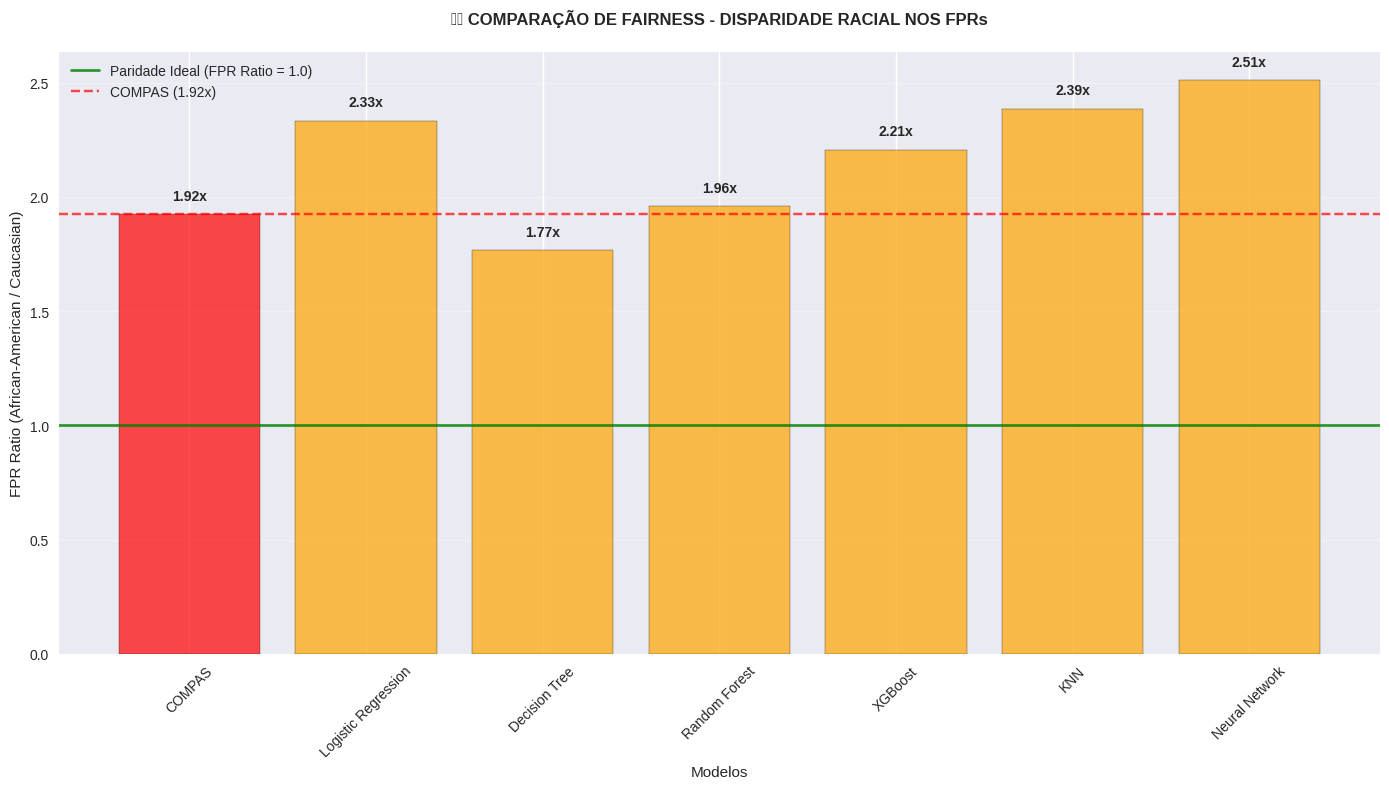

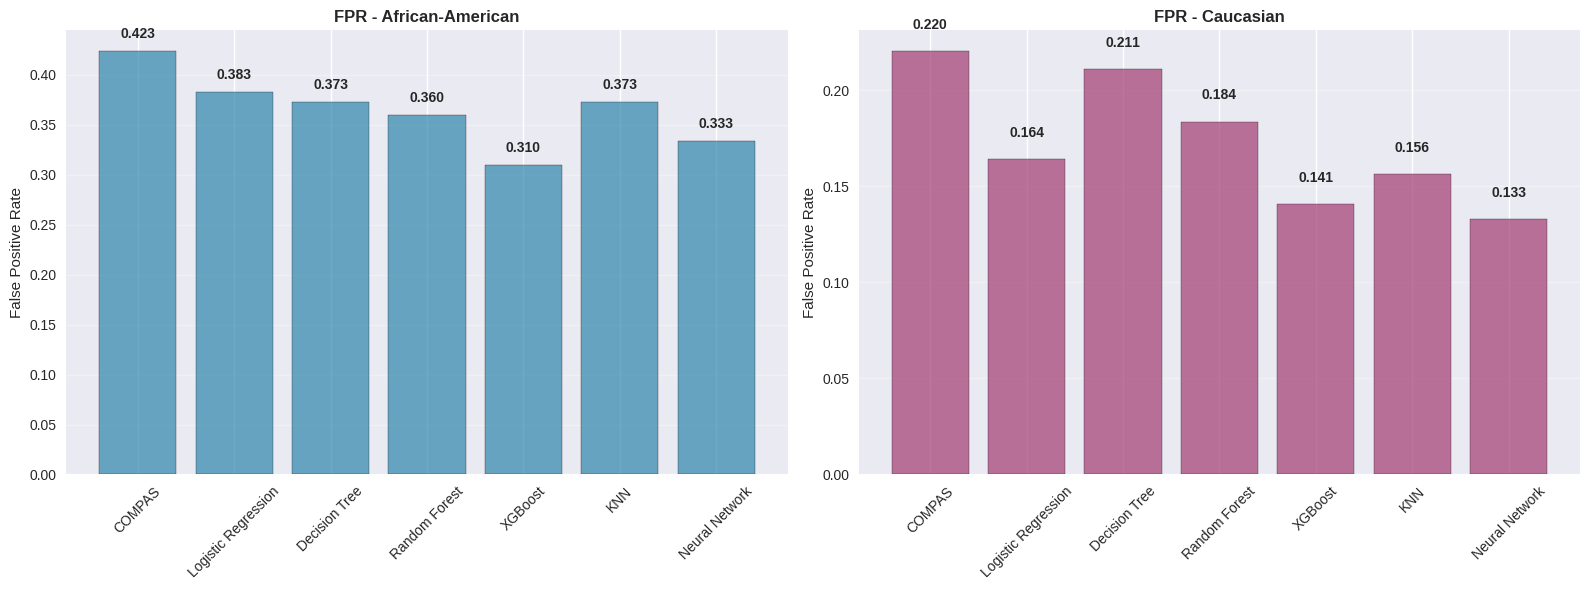

In [15]:
# =============================================================================
# 12.3 COMPARAÇÃO DE FAIRNESS (FPR RATIO)
# =============================================================================

print("⚖️ COMPARAÇÃO DE FAIRNESS (FPR RATIO)")

plt.figure(figsize=(14, 8))
fpr_ratios = df_comparativo['FPR Ratio']

colors_fpr = ['red' if 'COMPAS' in model else 'orange' for model in modelos_plot]
bars = plt.bar(modelos_plot, fpr_ratios, color=colors_fpr, alpha=0.7, edgecolor='black')

plt.axhline(y=1.0, color='green', linestyle='-', alpha=0.8, linewidth=2,
           label='Paridade Ideal (FPR Ratio = 1.0)')
plt.axhline(y=compas_fpr_ratio, color='red', linestyle='--', alpha=0.7,
           label=f'COMPAS ({compas_fpr_ratio:.2f}x)')
plt.xlabel('Modelos')
plt.ylabel('FPR Ratio (African-American / Caucasian)')
plt.title('⚖️ COMPARAÇÃO DE FAIRNESS - DISPARIDADE RACIAL NOS FPRs', fontweight='bold', pad=20)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for bar, valor in zip(bars, fpr_ratios):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{valor:.2f}x', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Plotar FPRs separados por raça
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# FPR African-American
fpr_aa = df_comparativo['FPR African-American']
bars1 = ax1.bar(modelos_plot, fpr_aa, color='#2E86AB', alpha=0.7, edgecolor='black')
ax1.set_title('FPR - African-American', fontweight='bold')
ax1.set_ylabel('False Positive Rate')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3, axis='y')

for bar, valor in zip(bars1, fpr_aa):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{valor:.3f}', ha='center', va='bottom', fontweight='bold')

# FPR Caucasian
fpr_caucasian = df_comparativo['FPR Caucasian']
bars2 = ax2.bar(modelos_plot, fpr_caucasian, color='#A23B72', alpha=0.7, edgecolor='black')
ax2.set_title('FPR - Caucasian', fontweight='bold')
ax2.set_ylabel('False Positive Rate')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

for bar, valor in zip(bars2, fpr_caucasian):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{valor:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

📈 ANÁLISE DAS MELHORIAS vs COMPAS


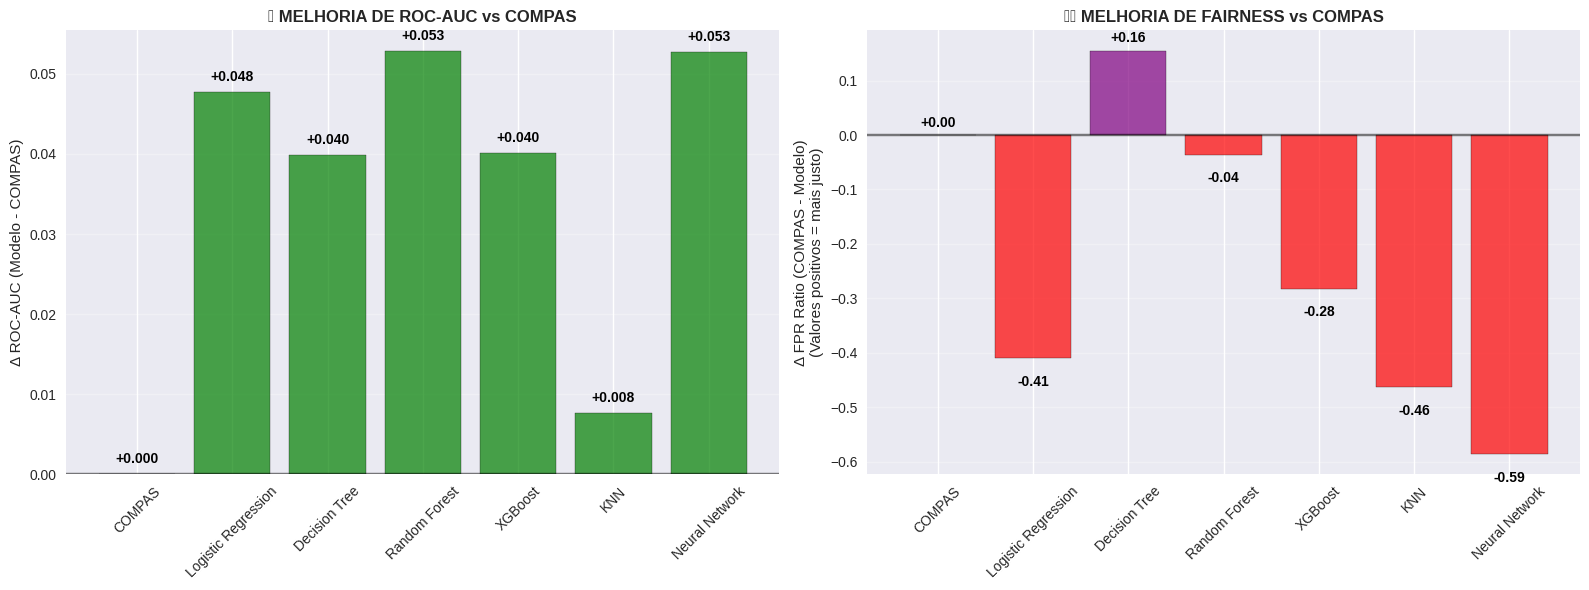

In [16]:
# =============================================================================
# 12.4 ANÁLISE DE MELHORIAS vs COMPAS
# =============================================================================

print("📈 ANÁLISE DAS MELHORIAS vs COMPAS")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Melhoria de AUC
melhoria_auc = df_comparativo['Melhoria AUC vs COMPAS']
colors_auc = ['red' if x <= 0 else 'green' for x in melhoria_auc]
bars1 = ax1.bar(modelos_plot, melhoria_auc, color=colors_auc, alpha=0.7, edgecolor='black')
ax1.axhline(y=0, color='black', linestyle='-', alpha=0.5)
ax1.set_title('📊 MELHORIA DE ROC-AUC vs COMPAS', fontweight='bold')
ax1.set_ylabel('Δ ROC-AUC (Modelo - COMPAS)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3, axis='y')

for bar, valor in zip(bars1, melhoria_auc):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.001 if valor >=0 else -0.003),
             f'{valor:+.3f}', ha='center', va='bottom' if valor >=0 else 'top',
             fontweight='bold', color='black')

# Melhoria de Fairness
melhoria_fairness = df_comparativo['Melhoria Fairness vs COMPAS']
colors_fairness = ['red' if x <= 0 else 'purple' for x in melhoria_fairness]
bars2 = ax2.bar(modelos_plot, melhoria_fairness, color=colors_fairness, alpha=0.7, edgecolor='black')
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)
ax2.set_title('⚖️ MELHORIA DE FAIRNESS vs COMPAS', fontweight='bold')
ax2.set_ylabel('Δ FPR Ratio (COMPAS - Modelo)\n(Valores positivos = mais justo)')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

for bar, valor in zip(bars2, melhoria_fairness):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.01 if valor >=0 else -0.03),
             f'{valor:+.2f}', ha='center', va='bottom' if valor >=0 else 'top',
             fontweight='bold', color='black')

plt.tight_layout()
plt.show()

In [17]:
# =============================================================================
# 12.5 RANKING E CONCLUSÕES FINAIS
# =============================================================================

print("🎯 RANKING FINAL E PRINCIPAIS CONCLUSÕES")
print("=" * 60)

# Ranking por ROC-AUC (excluindo COMPAS)
df_ranking_auc = df_comparativo[df_comparativo['Modelo'] != 'COMPAS'].sort_values('ROC-AUC', ascending=False)
df_ranking_fairness = df_comparativo[df_comparativo['Modelo'] != 'COMPAS'].sort_values('FPR Ratio')

print("🏆 RANKING POR PERFORMANCE (ROC-AUC):")
for i, (_, row) in enumerate(df_ranking_auc.iterrows(), 1):
    melhoria = row['Melhoria AUC vs COMPAS']
    print(f"   {i:1d}. {row['Modelo']:20} ROC-AUC: {row['ROC-AUC']:.4f} (Δ: {melhoria:+.4f})")

print(f"\n⚖️  RANKING POR FAIRNESS (FPR Ratio mais próximo de 1.0):")
for i, (_, row) in enumerate(df_ranking_fairness.iterrows(), 1):
    distancia_ideal = abs(row['FPR Ratio'] - 1.0)
    print(f"   {i:1d}. {row['Modelo']:20} FPR Ratio: {row['FPR Ratio']:.2f}x (distância do ideal: {distancia_ideal:.2f})")

# Encontrar os melhores modelos
melhor_auc_modelo = df_ranking_auc.iloc[0]['Modelo']
melhor_auc_valor = df_ranking_auc.iloc[0]['ROC-AUC']
melhor_auc_melhoria = df_ranking_auc.iloc[0]['Melhoria AUC vs COMPAS']

# Encontrar modelo mais justo (FPR Ratio mais próximo de 1.0)
df_ranking_fairness['distancia_ideal'] = abs(df_ranking_fairness['FPR Ratio'] - 1.0)
melhor_fairness_modelo = df_ranking_fairness.loc[df_ranking_fairness['distancia_ideal'].idxmin(), 'Modelo']
melhor_fairness_ratio = df_ranking_fairness.loc[df_ranking_fairness['distancia_ideal'].idxmin(), 'FPR Ratio']
melhor_fairness_distancia = df_ranking_fairness.loc[df_ranking_fairness['distancia_ideal'].idxmin(), 'distancia_ideal']

# Modelo com melhor equilíbrio (considerando ambos os critérios)
df_ranking_geral = df_comparativo[df_comparativo['Modelo'] != 'COMPAS'].copy()
df_ranking_geral['score_auc_normalizado'] = (df_ranking_geral['ROC-AUC'] - df_ranking_geral['ROC-AUC'].min()) / (df_ranking_geral['ROC-AUC'].max() - df_ranking_geral['ROC-AUC'].min())
df_ranking_geral['score_fairness_normalizado'] = 1 - (abs(df_ranking_geral['FPR Ratio'] - 1.0) / (df_ranking_geral['FPR Ratio'].max() - 1.0))
df_ranking_geral['score_balanceado'] = (df_ranking_geral['score_auc_normalizado'] + df_ranking_geral['score_fairness_normalizado']) / 2

melhor_balanceado_modelo = df_ranking_geral.loc[df_ranking_geral['score_balanceado'].idxmax(), 'Modelo']
melhor_balanceado_score = df_ranking_geral.loc[df_ranking_geral['score_balanceado'].idxmax(), 'score_balanceado']

print(f"\n🔍 PRINCIPAIS CONCLUSÕES:")
print("=" * 50)
print(f"🏆 MELHOR PERFORMANCE:")
print(f"   • Modelo: {melhor_auc_modelo}")
print(f"   • ROC-AUC: {melhor_auc_valor:.4f}")
print(f"   • Melhoria vs COMPAS: {melhor_auc_melhoria:+.4f}")

print(f"\n⚖️  MELHOR FAIRNESS:")
print(f"   • Modelo: {melhor_fairness_modelo}")
print(f"   • FPR Ratio: {melhor_fairness_ratio:.2f}x")
print(f"   • Distância do ideal: {melhor_fairness_distancia:.2f}")

print(f"\n🎯 MELHOR EQUILÍBRIO (Performance + Fairness):")
print(f"   • Modelo: {melhor_balanceado_modelo}")
print(f"   • Score Balanceado: {melhor_balanceado_score:.3f}")

print(f"\n💡 RECOMENDAÇÕES PARA O TCC:")
print("=" * 40)
print(f"   • Para MÁXIMA PERFORMANCE: {melhor_auc_modelo}")
print(f"   • Para MÁXIMA JUSTIÇA: {melhor_fairness_modelo}")
print(f"   • Para EQUILÍBRIO IDEAL: {melhor_balanceado_modelo}")

print(f"\n📊 RESUMO DO COMPORTAMENTO DOS MODELOS:")
print("=" * 45)
for modelo in df_ranking_geral['Modelo']:
    dados = df_ranking_geral[df_ranking_geral['Modelo'] == modelo].iloc[0]
    print(f"   • {modelo:20} | AUC: {dados['ROC-AUC']:.3f} | FPR Ratio: {dados['FPR Ratio']:.2f}x | Balanceado: {dados['score_balanceado']:.3f}")

🎯 RANKING FINAL E PRINCIPAIS CONCLUSÕES
🏆 RANKING POR PERFORMANCE (ROC-AUC):
   1. Random Forest        ROC-AUC: 0.7103 (Δ: +0.0528)
   2. Neural Network       ROC-AUC: 0.7102 (Δ: +0.0527)
   3. Logistic Regression  ROC-AUC: 0.7052 (Δ: +0.0477)
   4. XGBoost              ROC-AUC: 0.6976 (Δ: +0.0401)
   5. Decision Tree        ROC-AUC: 0.6973 (Δ: +0.0398)
   6. KNN                  ROC-AUC: 0.6651 (Δ: +0.0076)

⚖️  RANKING POR FAIRNESS (FPR Ratio mais próximo de 1.0):
   1. Decision Tree        FPR Ratio: 1.77x (distância do ideal: 0.77)
   2. Random Forest        FPR Ratio: 1.96x (distância do ideal: 0.96)
   3. XGBoost              FPR Ratio: 2.21x (distância do ideal: 1.21)
   4. Logistic Regression  FPR Ratio: 2.33x (distância do ideal: 1.33)
   5. KNN                  FPR Ratio: 2.39x (distância do ideal: 1.39)
   6. Neural Network       FPR Ratio: 2.51x (distância do ideal: 1.51)

🔍 PRINCIPAIS CONCLUSÕES:
🏆 MELHOR PERFORMANCE:
   • Modelo: Random Forest
   • ROC-AUC: 0.7103
   • M


🎯 MATRIZ PERFORMANCE vs FAIRNESS


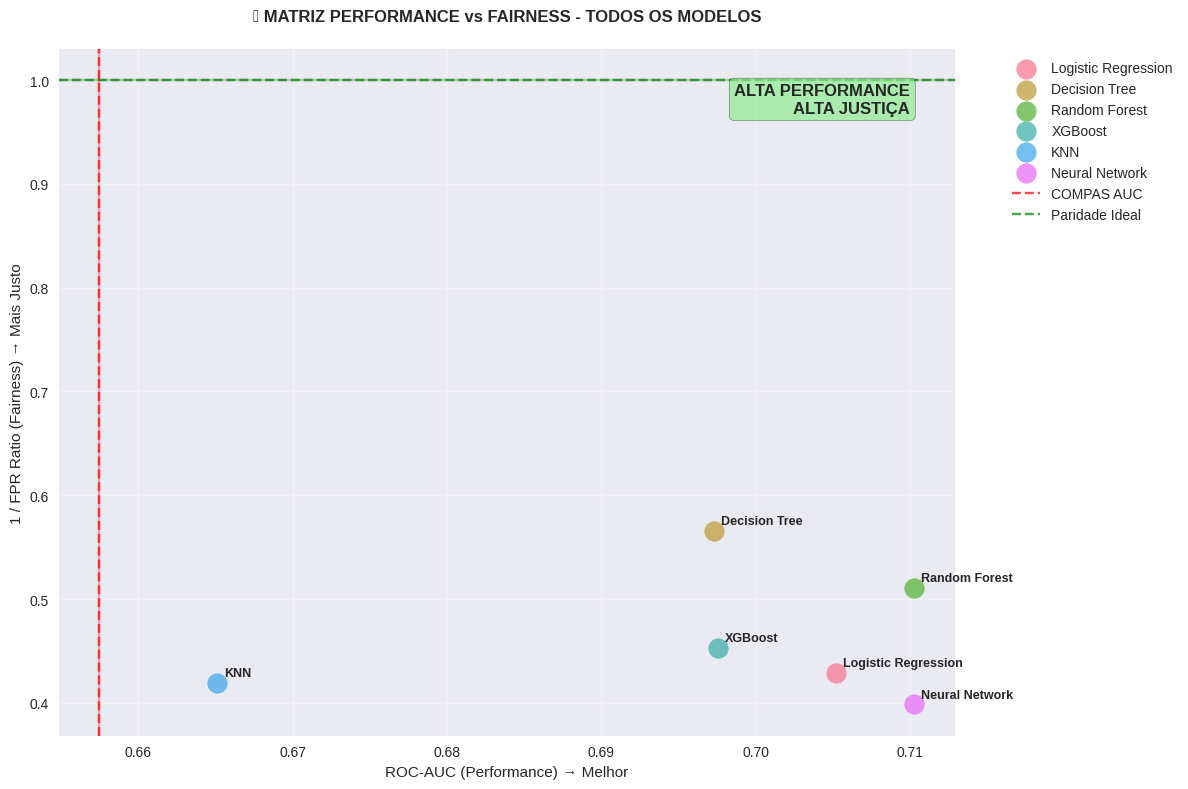


✅ ETAPA 2 CONCLUÍDA COM SUCESSO!
📈 6 modelos treinados e avaliados
⚖️  Análise completa de performance e fairness realizada
🎯 Prontos para a Etapa 3: Replicação das decisões do COMPAS
💾 Todos os resultados armazenados em 'resultados_gerais'


In [18]:
# =============================================================================
# 12.6 VISUALIZAÇÃO FINAL - MATRIZ PERFORMANCE vs FAIRNESS
# =============================================================================

print("\n🎯 MATRIZ PERFORMANCE vs FAIRNESS")

plt.figure(figsize=(12, 8))

# Criar scatter plot Performance vs Fairness
for i, modelo in enumerate(df_ranking_geral['Modelo']):
    dados = df_ranking_geral[df_ranking_geral['Modelo'] == modelo].iloc[0]
    x = dados['ROC-AUC']
    y = 1.0 / dados['FPR Ratio']  # Invertendo para valores mais altos = mais justos

    plt.scatter(x, y, s=200, alpha=0.7, label=modelo)
    plt.annotate(modelo, (x, y), xytext=(5, 5), textcoords='offset points',
                fontweight='bold', fontsize=9)

# Adicionar COMPAS como referência
plt.axvline(x=compas_auc, color='red', linestyle='--', alpha=0.7, label='COMPAS AUC')
plt.axhline(y=1.0, color='green', linestyle='--', alpha=0.7, label='Paridade Ideal')

plt.xlabel('ROC-AUC (Performance) → Melhor')
plt.ylabel('1 / FPR Ratio (Fairness) → Mais Justo')
plt.title('🎯 MATRIZ PERFORMANCE vs FAIRNESS - TODOS OS MODELOS', fontweight='bold', pad=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Adicionar quadrantes
plt.axhline(y=1.0, color='green', linestyle='-', alpha=0.3)
plt.axvline(x=compas_auc, color='red', linestyle='-', alpha=0.3)

plt.text(0.95, 0.95, 'ALTA PERFORMANCE\nALTA JUSTIÇA', transform=plt.gca().transAxes,
         fontsize=12, fontweight='bold', ha='right', va='top',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7))

plt.tight_layout()
plt.show()